In [22]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt

In [23]:
Us = sim.generate_Us(s=5,k=16,p=40,type='hard')

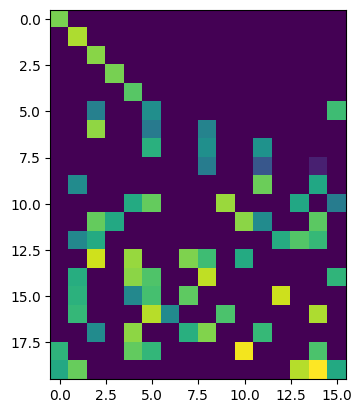

In [24]:
seed = 0
np.random.seed(seed)

n_tasks = 20
n_parcels = 16
V = np.zeros((n_tasks, n_parcels))

for task in range(n_tasks):
    if task < 5:
        # Each task activates a distinct set of parcels with strong and unique strengths
        parcel = task  # Activate a distinct parcel for each task
        V[task, parcel] = 1.0 + np.random.uniform(-0.3, 0.3)  # Higher noise for more variation

    elif 5 <= task < 10:
        # Next 2 tasks activate three distinct parcels with distinct strengths
        parcel_1 = (task * 3) % n_parcels
        parcel_2 = (parcel_1 + 3) % n_parcels
        parcel_3 = (parcel_2 + 3) % n_parcels
        V[task, [parcel_1, parcel_2, parcel_3]] = [0.8 + np.random.uniform(-0.3, 0.3),
                                                    0.6 + np.random.uniform(-0.3, 0.3),
                                                    0.4 + np.random.uniform(-0.3, 0.3)]

    else:
        # Randomly activate 5 parcels with unique patterns and scaling factors
        active_parcels = np.random.choice(n_parcels, size=5, replace=False)
        base_strength = 0.7
        for i, parcel in enumerate(active_parcels):
            V[task, parcel] = base_strength + (0.2 * i) + np.random.uniform(-0.2, 0.2)
            base_strength -= 0.1  # Decrease base strength for subsequent parcels

# Visualize the V matrix
plt.imshow(V)




In [25]:
# get the data 
y = V @ Us
noise_std = 1  # Adjust this value as needed

noise = np.random.normal(loc=0.0, scale=noise_std, size=y.shape)
y_noisy = y + noise


In [26]:
# test different methos
U_hat_ols = sim.estimate_Us_ols(y_noisy, V)
U_hat_NNLS = sim.estimate_Us_NNLS(y_noisy, V,max_iter=1000, tol=1e-6, learning_rate=1e-3)
U_hat_l2 = sim.estimate_Us_l2_regularization(y_noisy, V, alpha=0.1, max_iter=1000, tol=1e-6, learning_rate=1e-3)

In [27]:
mse_per_subject = np.zeros(Us.shape[0])
for subj in range(Us.shape[0]):
    mse = np.mean((Us[subj] - U_hat_ols[subj]) ** 2)
    mse_per_subject[subj] = mse
print("Average MSE ols across subjects:", np.mean(mse_per_subject))


Average MSE ols across subjects: 6.615715266807191


In [28]:
mse_per_subject = np.zeros(Us.shape[0])
for subj in range(Us.shape[0]):
    mse = np.mean((Us[subj] - U_hat_NNLS[subj]) ** 2)
    mse_per_subject[subj] = mse

print("Average MSE NNLS across subjects:", np.mean(mse_per_subject))

Average MSE NNLS across subjects: 0.11082804218170161


In [29]:
mse_per_subject = np.zeros(Us.shape[0])
for subj in range(Us.shape[0]):
    mse = np.mean((Us[subj] - U_hat_l2[subj]) ** 2)
    mse_per_subject[subj] = mse

print("Average MSE L2 across subjects:", np.mean(mse_per_subject))

Average MSE L2 across subjects: 0.10347457867706047


#